## Программа для записи данных с вибрацией

In [39]:
import os
import re
import csv
from collections import deque
from pymavlink import mavutil


BUFFER_SIZE = 100
FOLDER_NAME = "Data/NIR"
PORT = "14567"


def get_file_path():
    os.makedirs(FOLDER_NAME, exist_ok=True)
    
    max_file_number = 0
    for f in os.listdir(FOLDER_NAME):
        match = re.search(r'pixhawk_imu_data_(\d+)\.csv', f)
        if match:
            file_num = int(match.group(1))
            if file_num > max_file_number:
                max_file_number = file_num
                
    return os.path.join(FOLDER_NAME, f'pixhawk_imu_data_{max_file_number + 1}.csv')


def flush(packet_counter, buf, row, writer):
    buf.append(row)
    packet_counter += 1

    if packet_counter % 500 == 0:
        print(f"Packets: {packet_counter}")
    
    if len(buf) >= BUFFER_SIZE:
        writer.writerows(buf)
        buf.clear()

    return packet_counter


master = mavutil.mavlink_connection(f'udpin:0.0.0.0:{PORT}')
master.wait_heartbeat()
print("Connected to Pixhawk")

file_path = get_file_path()
f = open(file_path, 'w', newline='')
writer = csv.writer(f)

writer.writerow([
    'time_usec', 
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz',
    'mx', 'my', 'mz',
    'abs_pressure', 'diff_pressure', 'pressure_alt',
    'temperature', 'fields_updated', 'id',
    'vibration_imu_instance', 'vib_x', 'vib_y', 'vib_z',
    'clipping_0', 'clipping_1', 'clipping_2'
])

buf = deque()

print("LOGGING STARTED")

packet_counter = 0
try:
    while True:
        msg = master.recv_match(blocking=True)
        if not msg: continue

        # Обработка HIGHRES_IMU
        if msg.get_type() == 'HIGHRES_IMU':
            row = [
                msg.time_usec,
                msg.xacc, msg.yacc, msg.zacc,
                msg.xgyro, msg.ygyro, msg.zgyro,
                msg.xmag, msg.ymag, msg.zmag,
                msg.abs_pressure, msg.diff_pressure, msg.pressure_alt,
                msg.temperature, msg.fields_updated, msg.id,
                '', '', '', '', '', '', ''                    # Пустые vibration поля
            ]
            packet_counter = flush(packet_counter, buf, row, writer)

        # Обработка VIBRATION
        elif msg.get_type() == 'VIBRATION':
            row = [
                msg.time_usec,
                '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', 
                msg.id, 
                msg.vibration_x, msg.vibration_y, msg.vibration_z, 
                msg.clipping_0, msg.clipping_1, msg.clipping_2    
            ]
            packet_counter = flush(packet_counter, buf, row, writer)

except KeyboardInterrupt:
    print("STOPPING LOGGING")

finally:
    if buf: writer.writerows(buf)
    f.close()
    print(f"Data saved to {file_path}")

Connected to Pixhawk
LOGGING STARTED
Packets: 500
Packets: 1000
Packets: 1500
Packets: 2000
Packets: 2500
Packets: 3000
Packets: 3500
Packets: 4000
Packets: 4500
Packets: 5000
Packets: 5500
Packets: 6000
Packets: 6500
Packets: 7000
Packets: 7500
Packets: 8000
Packets: 8500
Packets: 9000
Packets: 9500
Packets: 10000
Packets: 10500
Packets: 11000
Packets: 11500
Packets: 12000
Packets: 12500
Packets: 13000
Packets: 13500
Packets: 14000
Packets: 14500
Packets: 15000
Packets: 15500
Packets: 16000
Packets: 16500
Packets: 17000
Packets: 17500
Packets: 18000
Packets: 18500
Packets: 19000
Packets: 19500
Packets: 20000
Packets: 20500
Packets: 21000
Packets: 21500
Packets: 22000
Packets: 22500
Packets: 23000
Packets: 23500
Packets: 24000
Packets: 24500
STOPPING LOGGING
Data saved to Data/NIR\pixhawk_imu_data_1.csv


## Программа для предварительного просмотра записанных данных

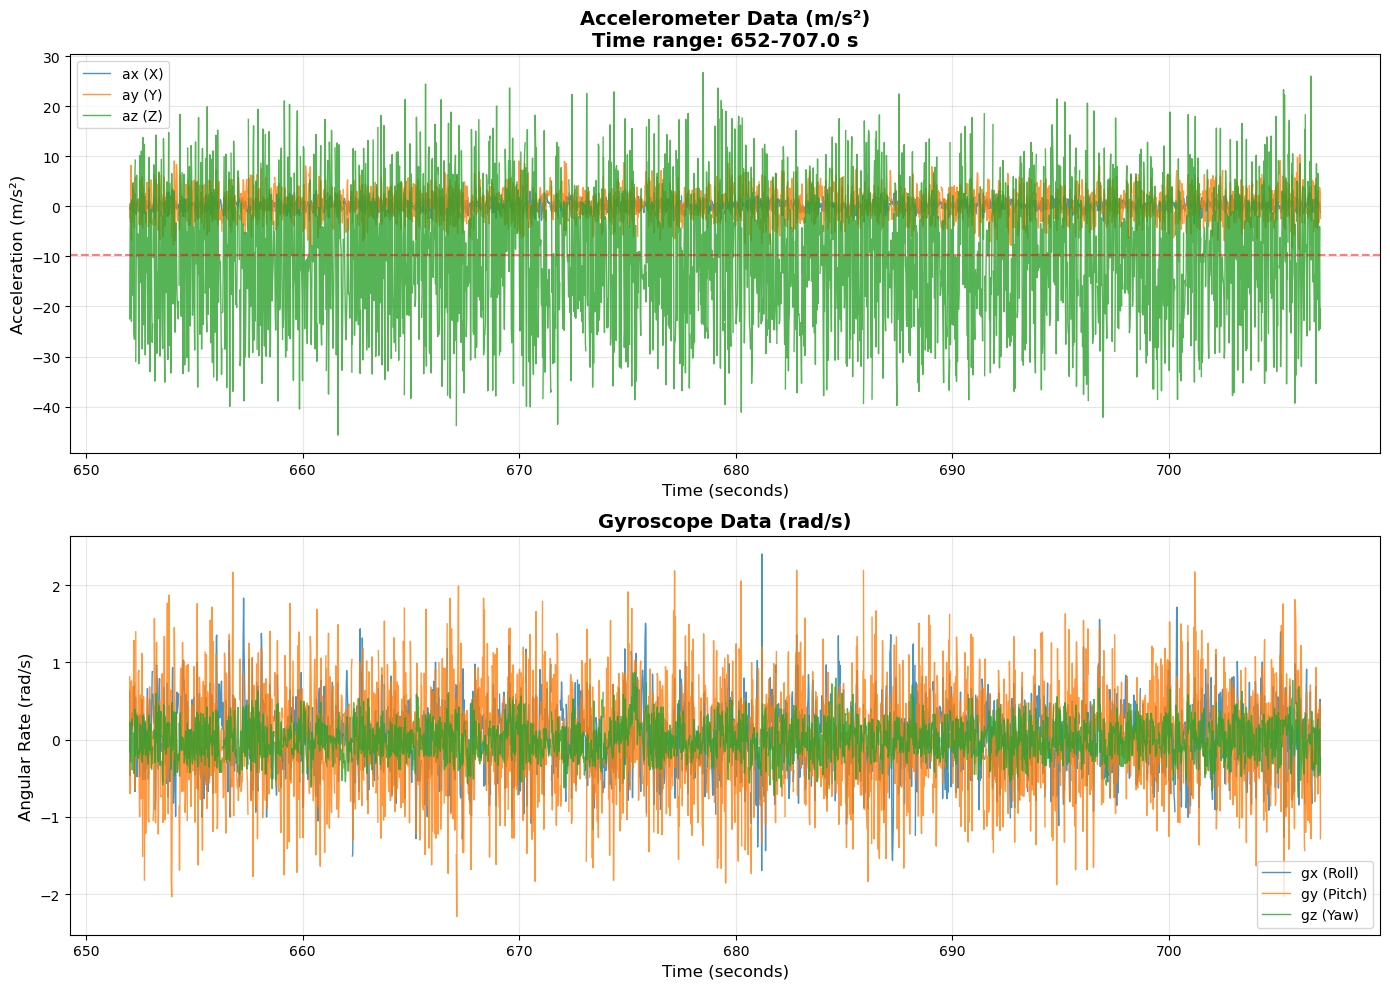

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_imu_data_with_time_range(csv_file, start_time_sec=0, end_time_sec=None):
    
    # Загрузка данных
    data = pd.read_csv(csv_file)
    
    # Преобразование времени из микросекунд в секунды
    start_time_us = data['time_usec'].iloc[0]
    data['time_sec'] = (data['time_usec'] - start_time_us) / 1_000_000.0
    
    # Фильтрация данных по заданному диапазону времени
    mask = data['time_sec'] >= start_time_sec
    if end_time_sec is not None:
        mask = mask & (data['time_sec'] <= end_time_sec)
    
    filtered_data = data[mask].copy()
    
    if len(filtered_data) == 0:
        print(f"Ошибка: Нет данных в диапазоне {start_time_sec} - {end_time_sec} секунд")
        return
    
    # Создание фигуры
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # График акселерометра
    ax1.plot(filtered_data['time_sec'], filtered_data['ax'], 
             label='ax (X)', alpha=0.8, linewidth=1)
    ax1.plot(filtered_data['time_sec'], filtered_data['ay'], 
             label='ay (Y)', alpha=0.8, linewidth=1)
    ax1.plot(filtered_data['time_sec'], filtered_data['az'], 
             label='az (Z)', alpha=0.8, linewidth=1)
    
    ax1.set_title(f'Accelerometer Data (m/s²)\nTime range: {start_time_sec}-{end_time_sec if end_time_sec else filtered_data["time_sec"].max():.1f} s', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Acceleration (m/s²)', fontsize=12)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Линия ускорения свободного падения
    ax1.axhline(y=-9.81, color='red', linestyle='--', alpha=0.5, label='g = 9.81 m/s²')
    
    # График гироскопа
    ax2.plot(filtered_data['time_sec'], filtered_data['gx'], 
             label='gx (Roll)', alpha=0.8, linewidth=1)
    ax2.plot(filtered_data['time_sec'], filtered_data['gy'], 
             label='gy (Pitch)', alpha=0.8, linewidth=1)
    ax2.plot(filtered_data['time_sec'], filtered_data['gz'], 
             label='gz (Yaw)', alpha=0.8, linewidth=1)
    
    ax2.set_title('Gyroscope Data (rad/s)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time (seconds)', fontsize=12)
    ax2.set_ylabel('Angular Rate (rad/s)', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


#####################################################

csv_file = "DATA/TEST_FLIGHT/flight_raw/PIXHAWK_TEST_FLIGHTS.csv" #"DATA/Raw_data/sm2_sm15_x1.csv"  # sm05_x_1.csv 

start_time = 0
end_time = None

start_time = 652
end_time = 707

#####################################################

plot_imu_data_with_time_range(csv_file, start_time, end_time)

## Программа для обрезки записанных данных

In [37]:
import pandas as pd
import numpy as np
import os

def trim_imu_data_and_save(csv_file, start_time_sec=0, end_time_sec=None, output_file=None, clas='none'):
    
    # Загрузка данных
    data = pd.read_csv(csv_file)
    
    
    # Преобразование времени в секунды
    start_time_us = data['time_usec'].iloc[0]
    data['time_sec'] = (data['time_usec'] - start_time_us) / 1_000_000.0
    
    # Полный диапазон исходных данных
    total_start = data['time_sec'].min()
    total_end = data['time_sec'].max()
    
    # Фильтрация данных
    mask = data['time_sec'] >= start_time_sec
    if end_time_sec is not None:
        mask = mask & (data['time_sec'] <= end_time_sec)
    
    trimmed_data = data[mask].copy()
    
    # Удаляем временную колонку в секундах (если нужна, можно оставить)
    if 'time_sec' in trimmed_data.columns:
        trimmed_data = trimmed_data.drop(columns=['time_sec'])
    
    # Генерация имени выходного файла, если не указано
    if output_file is None:
        # Создаем папку для обрезанных данных, если её нет
        output_dir = "DATA"
        os.makedirs(output_dir, exist_ok=True)
        
        # Базовое имя файла
        base_name = os.path.basename(csv_file)
        name_without_ext = os.path.splitext(base_name)[0]
        
        # Формируем имя файла с диапазоном времени
        time_range_str = f"{start_time_sec:.1f}to{end_time_sec if end_time_sec else total_end:.1f}s"
        # output_file = os.path.join(output_dir, f"{name_without_ext}_{clas}_trimmed_{time_range_str}.csv")
        output_file = os.path.join(output_dir, f"WAR_trimmed_{time_range_str}.csv")
    
    # Сохранение в CSV
    trimmed_data.to_csv(output_file, index=False)
    
    print(f"Сохранено: \t\t{len(trimmed_data)/len(data)*100:.1f}% исходных данных")
    time_length = (trimmed_data['time_usec'].iloc[-1] - trimmed_data['time_usec'].iloc[0])/1_000_000
    
    print(f"Длительность: \t\t{int(time_length // 60)} минут {time_length - (time_length // 60 * 60):.0f} секунд")
    print(f"Диапазон времени: \t{start_time_sec} - {end_time_sec if end_time_sec else 'конец'} секунд")
    
    return trimmed_data, output_file


#####################################################

clas='none'
csv_file = "DATA/TEST_FLIGHT/flight_raw/PIXHAWK_TEST_FLIGHTS.csv"
output_file = "DATA/TEST_FLIGHT/flights_trimmed/sm05_x3.csv"  # sm05_x_1.csv 

start_time = 0
end_time = None

start_time = 278
end_time = 323

start_time = 410
end_time = 455

start_time = 540
end_time = 595

start_time = 652
end_time = 707

#####################################################

trimmed_data, saved_file = trim_imu_data_and_save(
    csv_file=csv_file,
    start_time_sec=start_time,
    end_time_sec=end_time,
    output_file=output_file,
    clas=clas
)

if trimmed_data is not None: print(f"\nДанные сохранены в: \t{saved_file}")

Сохранено: 		7.8% исходных данных
Длительность: 		0 минут 55 секунд
Диапазон времени: 	652 - 707 секунд

Данные сохранены в: 	DATA/TEST_FLIGHT/flights_trimmed/sm05_x3.csv
